# Кластеризация сигналов сцинтилляционного детектора

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.stats import mode

sns.set_theme(style='whitegrid')
np.random.seed(42)

## Результат на Kaggle

скрин

## EDA

Посмотрим на исходные данные.

In [2]:
dataset = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
print('Размерность:', dataset.shape)
dataset.head()

Размерность: (23479, 500)


,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [3]:
print('Пропуски:', dataset.isna().sum().sum())
print('Дубликаты строк:', dataset.duplicated().sum())
dataset.describe().T.head(10)

Пропуски: 0
Дубликаты строк: 0


,count,mean,std,min,25%,50%,75%,max
0,23479.0,14822.972316,2.805884,14812.0,14821.0,14823.0,14824.0,14834.0
1,23479.0,14822.958474,2.833516,14812.0,14821.0,14823.0,14824.0,14835.0
2,23479.0,14822.970016,2.840755,14812.0,14821.0,14823.0,14825.0,14834.0
3,23479.0,14822.989991,2.852066,14811.0,14821.0,14823.0,14825.0,14835.0
4,23479.0,14823.003961,2.833412,14812.0,14821.0,14823.0,14825.0,14834.0
5,23479.0,14822.978619,2.836271,14812.0,14821.0,14823.0,14824.0,14835.0
6,23479.0,14822.968610,2.831241,14812.0,14821.0,14823.0,14824.0,14835.0
7,23479.0,14822.954470,2.827526,14811.0,14821.0,14823.0,14824.0,14833.0
8,23479.0,14822.963670,2.846291,14812.0,14821.0,14823.0,14824.0,14834.0
9,23479.0,14822.968908,2.814655,14809.0,14821.0,14823.0,14824.0,14834.0


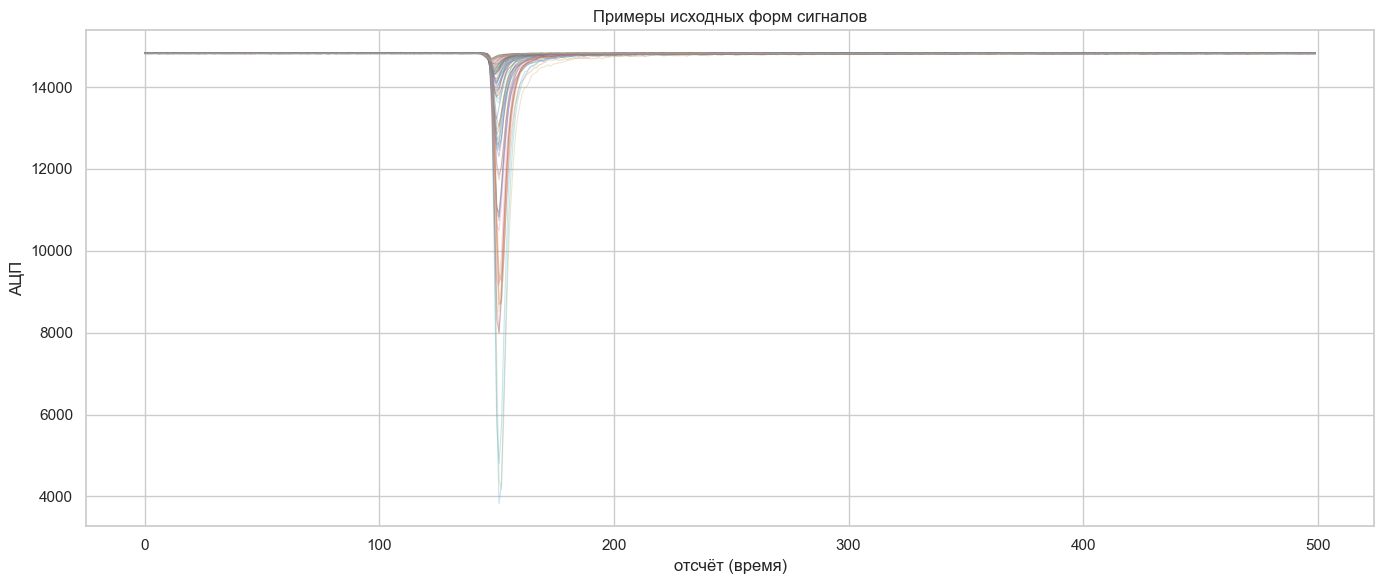

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
idx = np.linspace(0, len(dataset) - 1, 80, dtype=int)
dataset.iloc[idx].T.plot(ax=ax, legend=False, alpha=0.35, linewidth=0.8)
ax.set_title('Примеры исходных форм сигналов')
ax.set_xlabel('отсчёт (время)')
ax.set_ylabel('АЦП')
plt.tight_layout()
plt.show()

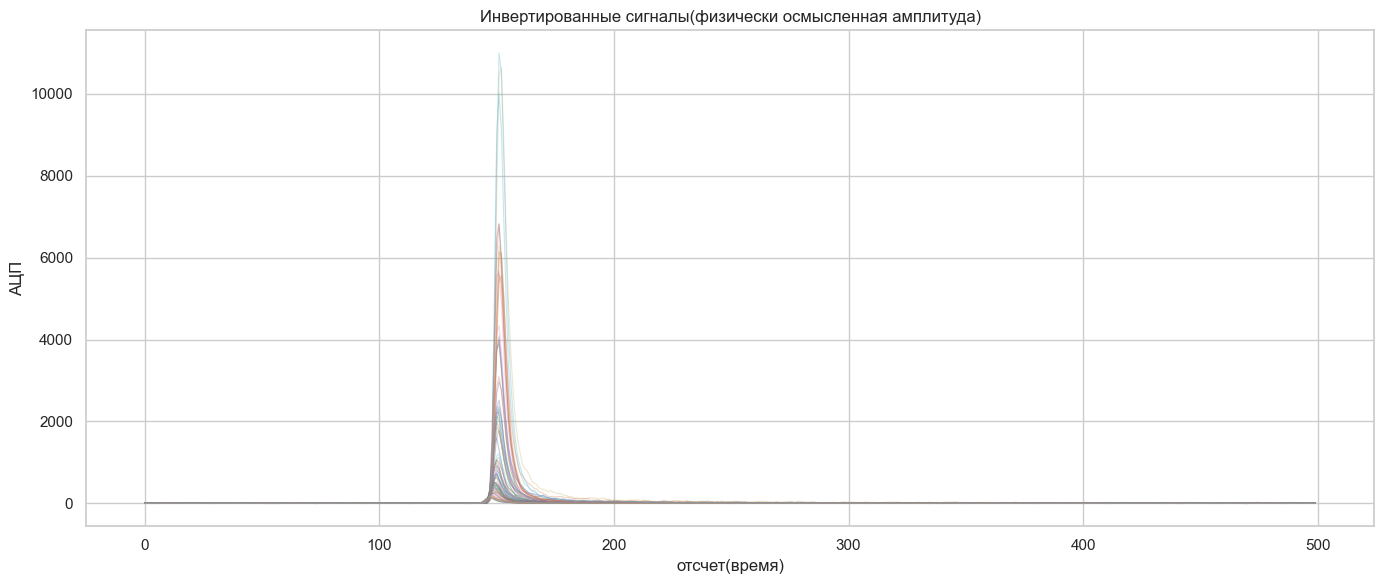

In [5]:
inverted = 2**14 - dataset - 1560
fig, ax = plt.subplots(figsize=(14, 6))
inverted.iloc[idx].T.plot(ax=ax, legend=False, alpha=0.35, linewidth=0.8)
ax.set_title('Инвертированные сигналы(физически осмысленная амплитуда)')
ax.set_xlabel('отсчет(время)')
ax.set_ylabel('АЦП')
plt.tight_layout()
plt.show()

## Feature Engineering

Из каждой формы сигнала извлекаются физически интерпретируемые признаки PSD(интегралы prompt/tail, отношения хвоста, пик, время нарастания/спада и другие).

In [6]:
def extract_features(waveforms: np.ndarray) -> pd.DataFrame:
    W = waveforms.astype(np.float64)
    baseline = np.median(W[:, :50], axis=1, keepdims=True)
    pulse = np.maximum(W - baseline, 0)
    total = pulse.sum(axis=1) + 1e-9
    peak = pulse.max(axis=1)
    peak_idx = pulse.argmax(axis=1)
    prompt = pulse[:, 20:120].sum(axis=1)
    tail = pulse[:, 120:350].sum(axis=1)
    early = pulse[:, :120].sum(axis=1)
    late = pulse[:, 200:].sum(axis=1)
    half = 0.5 * peak[:, None]
    above = pulse >= half
    rise = np.argmax(above, axis=1)
    fall = pulse.shape[1] - np.argmax(above[:, ::-1], axis=1)
    rise_10 = np.argmax(pulse >= 0.1 * peak[:, None], axis=1)
    rise_90 = np.argmax(pulse >= 0.9 * peak[:, None], axis=1)
    rise_time_10_90 = rise_90 - rise_10
    skewness = ((pulse - pulse.mean(axis=1, keepdims=True))**3).mean(axis=1) / \
               (pulse.std(axis=1)**3 + 1e-9)
    kurtosis = ((pulse - pulse.mean(axis=1, keepdims=True))**4).mean(axis=1) / \
               (pulse.std(axis=1)**4 + 1e-9) - 3
    fft_features = np.fft.rfft(pulse, axis=1)
    spectral_centroid = np.abs(fft_features * np.arange(fft_features.shape[1])).sum(axis=1) / \
                        (np.abs(fft_features).sum(axis=1) + 1e-9)
    
    return pd.DataFrame({
        'total_charge': total,
        'peak': peak,
        'std': pulse.std(axis=1),
        'prompt_charge': prompt,
        'tail_charge': tail,
        'psd_tail_prompt': tail / (prompt + 1e-9),
        'psd_late_early': late / (early + 1e-9),
        'rise_time': rise,
        'fall_time': fall,
        'pulse_width': fall - rise,
        'peak_index': peak_idx,
        'rise_time_10_90': rise_time_10_90,
        'skewness': skewness,
        'kurtosis': kurtosis,
        'spectral_centroid': spectral_centroid,
    })

waves = dataset.values
features = extract_features(waves)
features.head()

,total_charge,peak,std,prompt_charge,tail_charge,psd_tail_prompt,psd_late_early,rise_time,fall_time,pulse_width,peak_index,rise_time_10_90,skewness,kurtosis,spectral_centroid
0,244.0,8.0,1.217315,69.0,73.0,1.057971,1.865854,14,491,477,25,24,3.174452,11.124561,119.618710
1,303.0,5.5,1.211926,104.5,91.5,0.875598,1.355372,3,491,488,26,23,2.393631,5.287706,112.925154
2,295.0,8.0,1.249760,97.0,89.0,0.917526,1.398230,38,488,450,338,335,2.543062,6.901682,116.526621
3,503.0,9.0,1.677487,145.0,166.0,1.144828,1.713450,0,496,496,320,320,1.912416,3.153361,116.482360
4,305.0,6.0,1.257736,78.0,121.0,1.551282,1.867347,4,500,496,36,36,2.488998,6.082679,120.811184


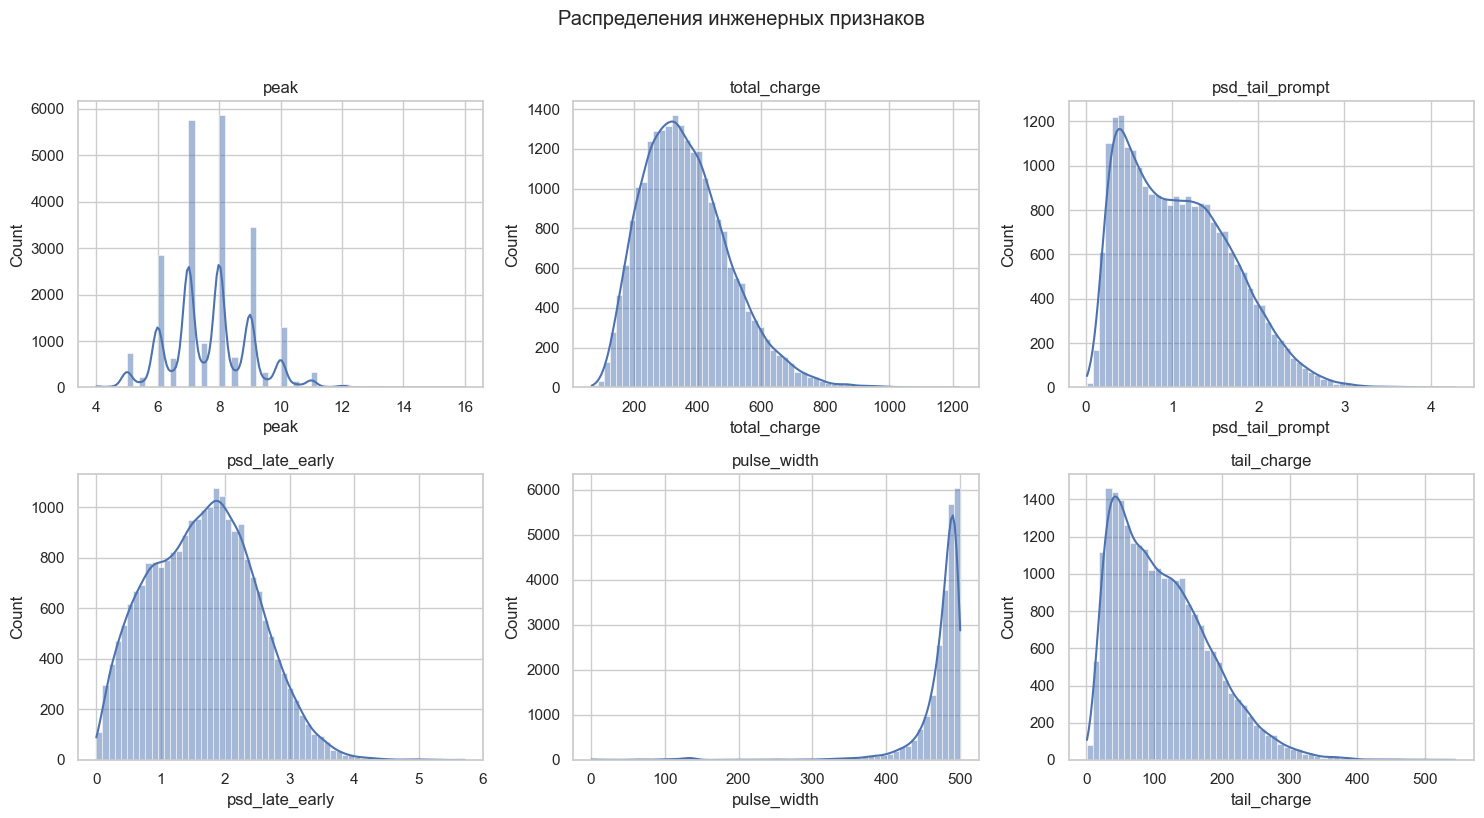

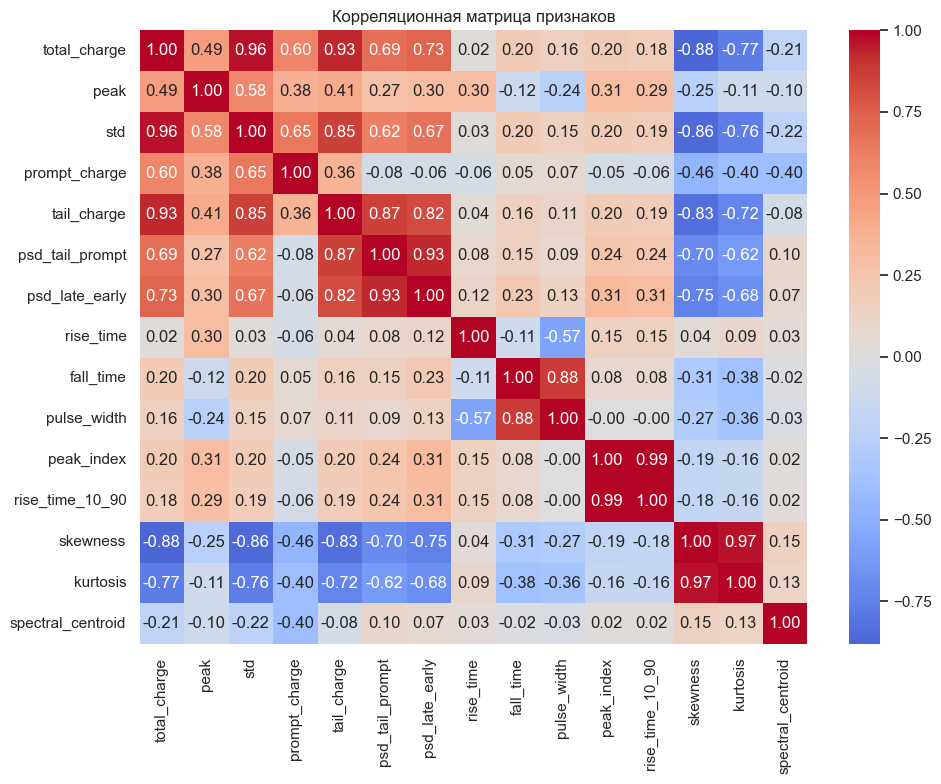

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['peak', 'total_charge', 'psd_tail_prompt', 'psd_late_early', 'pulse_width', 'tail_charge']
for ax, col in zip(axes.ravel(), cols):
    sns.histplot(features[col], bins=60, ax=ax, kde=True)
    ax.set_title(col)
plt.suptitle('Распределения инженерных признаков', y=1.02)
plt.tight_layout()
plt.show()

corr = features.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

Нормализуем признаки.

In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(features)
feature_names = features.columns.tolist()
print('Матрица признаков:', X.shape)

Матрица признаков: (23479, 15)


Добавим PCA-признаки для улучшения прогноза.

In [9]:
scaler = StandardScaler()
waves_scaled = scaler.fit_transform(waves)
pca = PCA(n_components=20, random_state=42)
pca_features = pca.fit_transform(waves_scaled)
X_extended = np.hstack([X, pca_features])

## Кластеризация

Воспользуемся следующей стратегией: аномалии(кластер с меткой 2) будем получать через Isolation Forest, а оставшиеся делить при помощи K-means, GMM или агломеративной кластеризации.

In [10]:
def cluster_two_step(X, contamination, model):
    iso = IsolationForest(contamination=contamination, random_state=42, n_jobs=-1)
    normal = iso.fit_predict(X) == 1
    labels = np.full(X.shape[0], 2, dtype=int)
    #0 и 1 упорядочим по PSD(короткий/длинный хвост)
    psd_idx = feature_names.index('psd_tail_prompt')
    if model == 'kmeans':
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
        sub = kmeans.fit_predict(X[normal])
    elif model == 'gmm':
        gmm = GaussianMixture(
            n_components=2,
            covariance_type='full',
            random_state=42,
            n_init=3,
            init_params='k-means++'
        )
        sub = gmm.fit_predict(X[normal])
    elif model == 'agglomerative':
        agl = AgglomerativeClustering(n_clusters=2)
        sub = agl.fit_predict(X[normal])
    else:
        sub = ensemble_clustering(X[normal], 2, psd_idx)
    labels[normal] = sub
    c0, c1 = 0, 1
    if X[labels == c0, psd_idx].mean() > X[labels == c1, psd_idx].mean():
        c0, c1 = c1, c0
    mapping = {old: new for old, new in zip([0, 1, 2], [c0, c1, 2])}
    return np.array([mapping[l] for l in labels]), iso


def ensemble_clustering(X, n_clusters, psd_feature_idx):
    """Голосование между KMeans, GMM, Agglomerative"""
    models = [
        KMeans(n_clusters=n_clusters, random_state=42, n_init=20),
        GaussianMixture(n_components=n_clusters,
                        random_state=42,
                        covariance_type='full',
                        n_init=3,
                        init_params='k-means++'),
        AgglomerativeClustering(n_clusters=n_clusters)
    ]
    
    predictions = np.zeros((len(X), len(models)), dtype=int)
    for i, model in enumerate(models):
        pred = model.fit_predict(X)
        mean_0 = np.mean(X[pred == 0, psd_feature_idx])
        mean_1 = np.mean(X[pred == 1, psd_feature_idx])
        if mean_0 > mean_1:
            pred = 1 - pred
        predictions[:, i] = pred
    final_labels, _ = mode(predictions.astype(int), axis=1, keepdims=False)
    return final_labels

def eval_clustering(X, labels, sample_size=5000):
    n = len(labels)
    if len(np.unique(labels)) < 2:
        return {'silhouette': np.nan, 'davies_bouldin': np.nan, 'calinski_harabasz': np.nan}
    rng = np.random.RandomState(42)
    idx = rng.choice(n, size=min(sample_size, n), replace=False)
    Xs, ls = X[idx], labels[idx]
    return {
        'silhouette': silhouette_score(Xs, ls),
        'davies_bouldin': davies_bouldin_score(Xs, ls),
        'calinski_harabasz': calinski_harabasz_score(Xs, ls),
    }

Сравним стратегии по 3 метрикам кластеризации.

In [11]:
results = []
for contamination in [0.04, 0.05, 0.08, 0.10, 0.12]:
    for method in ['kmeans', 'gmm', 'agglomerative', 'ensemble']:
        labels, _ = cluster_two_step(X_extended, contamination, method)
        m = eval_clustering(X_extended, labels)
        m.update({'model': f'IsolationForest+{method}', 'contamination': contamination})
        m['cluster_sizes'] = str(np.bincount(labels, minlength=3).tolist())
        results.append(m)

compare_df = pd.DataFrame(results).sort_values('silhouette', ascending=False)
compare_df

,silhouette,davies_bouldin,calinski_harabasz,model,contamination,cluster_sizes
2,0.434526,5.916562,1367.397582,IsolationForest+agglomerative,0.04,"[2545, 19994, 940]"
3,0.389905,3.456079,1617.044832,IsolationForest+ensemble,0.04,"[4872, 17667, 940]"
0,0.389844,3.453283,1617.397553,IsolationForest+kmeans,0.04,"[4880, 17659, 940]"
4,0.375050,3.704599,1557.440519,IsolationForest+kmeans,0.05,"[4926, 17379, 1174]"
10,0.367661,7.468345,1266.301760,IsolationForest+agglomerative,0.08,"[3136, 18464, 1879]"
14,0.347210,7.343677,1185.952362,IsolationForest+agglomerative,0.10,"[3075, 18056, 2348]"
8,0.333169,5.001574,1357.475591,IsolationForest+kmeans,0.08,"[4916, 16684, 1879]"
11,0.333165,5.004917,1356.554609,IsolationForest+ensemble,0.08,"[4909, 16691, 1879]"
18,0.312179,6.781534,1052.729584,IsolationForest+agglomerative,0.12,"[2911, 17750, 2818]"
12,0.311743,5.639069,1268.447189,IsolationForest+kmeans,0.10,"[4874, 16257, 2348]"


Лучшей моделью является связка IsolationForest с contamination = 0.04 и K-means

In [12]:
final_labels, final_iso = cluster_two_step(X_extended, 0.04, 'kmeans')
print('Размеры кластеров(0, 1, 2):', np.bincount(final_labels, minlength=3))

summary = features.copy()
summary['cluster'] = final_labels
summary.groupby('cluster').mean().round(3)

Размеры кластеров(0, 1, 2): [ 4880 17659   940]


,total_charge,peak,std,prompt_charge,tail_charge,psd_tail_prompt,psd_late_early,rise_time,fall_time,pulse_width,peak_index,rise_time_10_90,skewness,kurtosis,spectral_centroid
cluster,,,,,,,,,,,,,,,
0,244.184,7.135,1.179,106.949,41.886,0.395,0.707,8.054,484.298,476.244,133.284,131.417,2.925,8.922,117.091
1,402.495,7.819,1.445,105.272,133.199,1.282,1.952,11.546,487.508,475.963,217.720,214.246,2.088,4.198,117.799
2,295.890,8.205,1.227,108.399,82.573,0.673,0.914,35.001,385.747,350.746,165.333,159.277,3.128,11.970,116.974


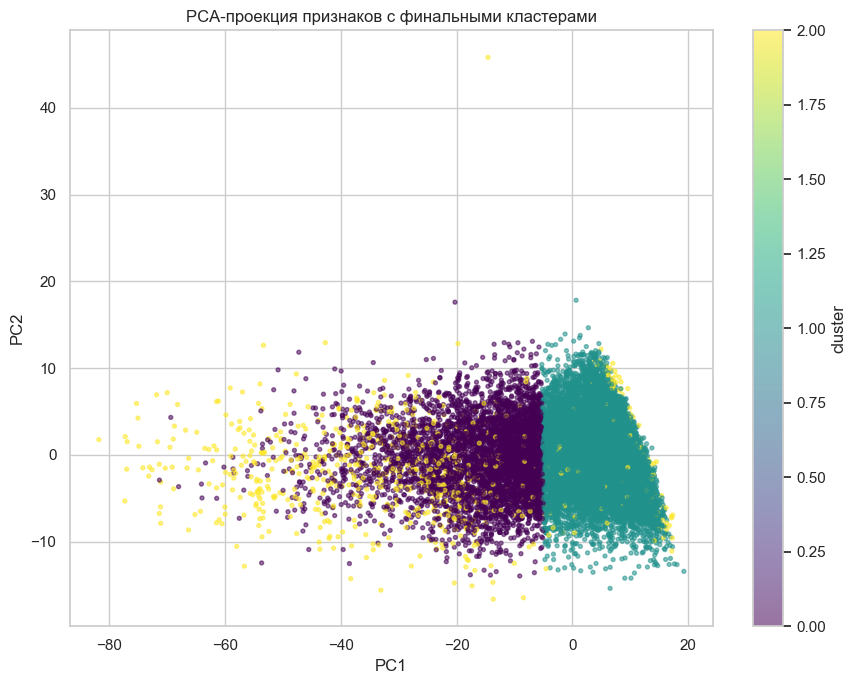

In [13]:
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_extended)
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X2[:, 0], X2[:, 1], c=final_labels, cmap='viridis', s=8, alpha=0.55)
plt.colorbar(scatter, label='cluster')
plt.title('PCA-проекция признаков с финальными кластерами')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

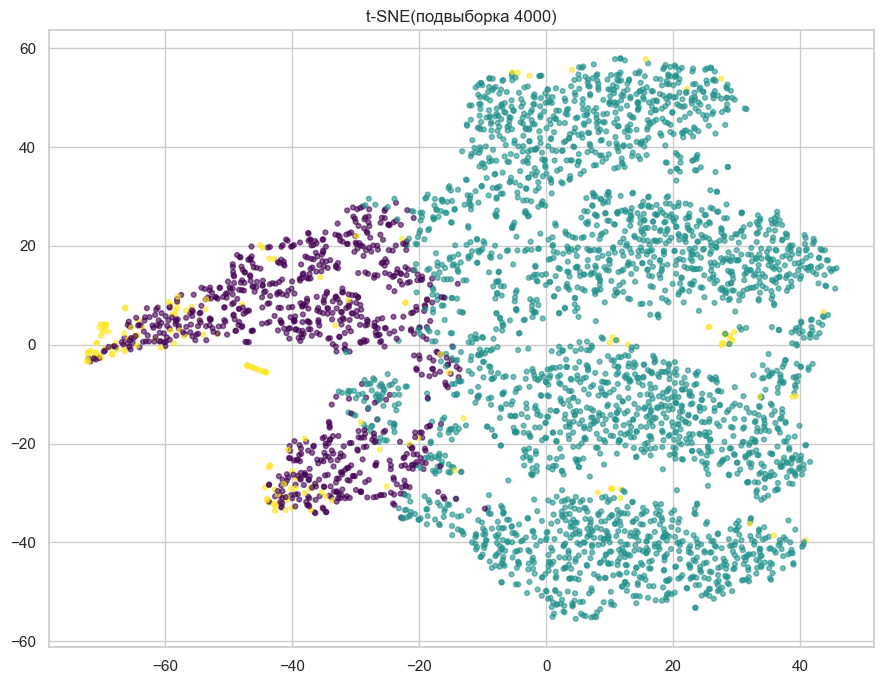

In [14]:
sample_idx = np.random.RandomState(42).choice(len(X), size=4000, replace=False)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, learning_rate='auto')
X_tsne = tsne.fit_transform(X_extended[sample_idx])
plt.figure(figsize=(9, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=final_labels[sample_idx], cmap='viridis', s=12, alpha=0.6)
plt.title('t-SNE(подвыборка 4000)')
plt.tight_layout()
plt.show()

Разделение прошло достаточно хорошо.

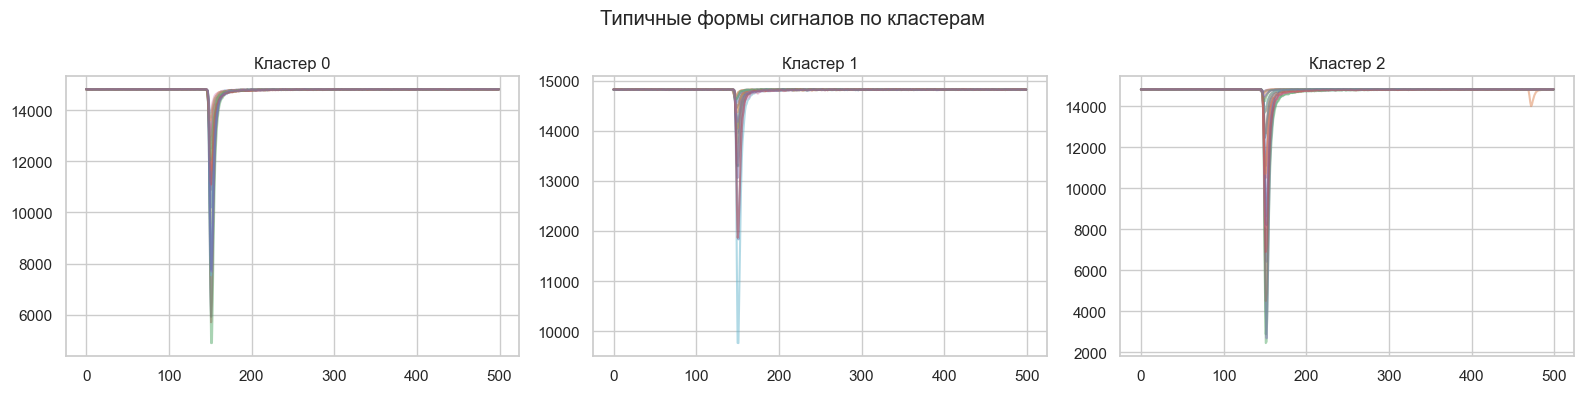

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for cl, ax in zip([0, 1, 2], axes):
    sub = dataset.loc[summary['cluster'] == cl].sample(min(25, (summary['cluster'] == cl).sum()), random_state=42)
    sub.T.plot(ax=ax, legend=False, alpha=0.5)
    ax.set_title(f'Кластер {cl}')
plt.suptitle('Типичные формы сигналов по кластерам')
plt.tight_layout()
plt.show()

## Выгрузка для Kaggle

In [16]:
submission = pd.DataFrame({'index': np.arange(len(final_labels)), 'cluster': final_labels.astype(int)})
submission.to_csv('submission.csv', index=False)
submission.head(10)

,index,cluster
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1
5,5,1
6,6,1
7,7,1
8,8,1
9,9,0


## Выводы

1. Сырые формы сигналов преобразованы в компактный набор PSD-признаков, отражающих энергию импульса и вклад медленного компонента(хвоста), статистические и PCA признаки.
2. Сравнены двухэтапные схема: **Isolation Forest**(аномалии) + **K-means**/**GMM**/**агломеративная кластеризация**/**ансамбль**(две физические группы).
3. Лучшая схема выбрана по метрикам внутренней валидации на подвыборке при подборе `contamination` и второго алгоритма.
4. Кластеры 0 и 1 упорядочены по среднему `psd_tail_prompt`. Интерпретация: разделение по форме хвоста импульса, кластер 2 - выбросы/смешанные сигналы.